In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


In [2]:
cwd = Path.cwd()

if (cwd / "requirements.txt").exists():
    project_root = cwd
else:
    project_root = cwd.parent

processed_file = project_root / "data" / "processed" / "SPY_daily.csv"
raw_file = project_root / "data" / "raw" / "SPY_daily.csv"
raw_file_alt = project_root / "data" / "raw" / "SPY_daily_raw.csv"

if processed_file.exists():
    data_file = processed_file
elif raw_file.exists():
    data_file = raw_file
elif raw_file_alt.exists():
    data_file = raw_file_alt
else:
    raise FileNotFoundError("No encuentro el CSV de SPY.")

print("Raíz del proyecto:", project_root)
print("Archivo usado:", data_file)

Raíz del proyecto: c:\Users\usuario\Documents\GitHub\QuantLab
Archivo usado: c:\Users\usuario\Documents\GitHub\QuantLab\data\processed\SPY_daily.csv


In [3]:
spy = pd.read_csv(data_file, index_col=0, parse_dates=True)

spy.head()

,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
1993-01-29,24.113268,43.93750,43.96875,43.75000,43.96875,1003200
1993-02-01,24.284761,44.25000,44.25000,43.96875,43.96875,480500
1993-02-02,24.336224,44.34375,44.37500,44.12500,44.21875,201300
1993-02-03,24.593477,44.81250,44.84375,44.37500,44.40625,529400
1993-02-04,24.696363,45.00000,45.09375,44.46875,44.96875,531500


In [4]:
spy.shape

(8413, 6)

In [5]:
spy.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 8413 entries, 1993-01-29 to 2026-07-02
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Adj Close  8413 non-null   float64
 1   Close      8413 non-null   float64
 2   High       8413 non-null   float64
 3   Low        8413 non-null   float64
 4   Open       8413 non-null   float64
 5   Volume     8413 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 460.1 KB


In [6]:
spy.columns

Index(['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='str')

In [7]:
spy.index.min(), spy.index.max()

(Timestamp('1993-01-29 00:00:00'), Timestamp('2026-07-02 00:00:00'))

In [8]:
spy.isna().sum()

Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64

In [9]:
spy["Adj Close"].head()

Date
1993-01-29    24.113268
1993-02-01    24.284761
1993-02-02    24.336224
1993-02-03    24.593477
1993-02-04    24.696363
Name: Adj Close, dtype: float64

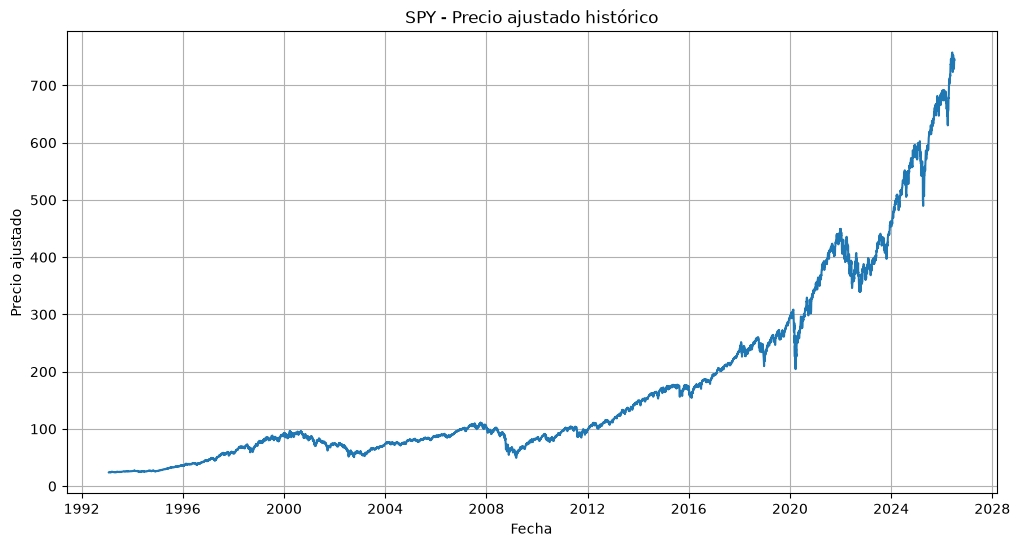

In [10]:
plt.figure(figsize=(12, 6))
plt.plot(spy.index, spy["Adj Close"])
plt.title("SPY - Precio ajustado histórico")
plt.xlabel("Fecha")
plt.ylabel("Precio ajustado")
plt.grid(True)
plt.show()

## Observaciones iniciales

El precio ajustado de SPY muestra una tendencia creciente de largo plazo.

Se aprecian varios periodos de caídas importantes, especialmente durante crisis de mercado.

El gráfico también sugiere que la escala lineal puede hacer que los movimientos recientes parezcan visualmente más grandes que los movimientos antiguos.

En próximos análisis será necesario estudiar rendimientos y drawdowns, no solo precios.